 CELL 1 — Mount Drive + Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

BASE_DIR = '/content/drive/MyDrive/mars_project'

backbone = load_model(os.path.join(BASE_DIR, 'mars_phase1_efficientnet.keras'))
print(f"Backbone loaded — {len(backbone.layers)} layers.")

with open(os.path.join(BASE_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

CLASS_NAMES  = list(label_encoder.classes_)
NUM_CLASSES  = len(CLASS_NAMES)
print("Known classes:", CLASS_NAMES)

Mounted at /content/drive
Backbone loaded — 9 layers.
Known classes: [np.str_('cracked'), np.str_('gravel'), np.str_('sand'), np.str_('sedimentary')]


CELL 2 — Build feature extractor from backbone

In [2]:
dense_layers = [l for l in backbone.layers
                if isinstance(l, tf.keras.layers.Dense)]
print("Dense layers:", [(l.name, l.units) for l in dense_layers])

# Dense order: Dense(256) → Dense(128) → Dense(num_classes)
# We want Dense(128) → index -2
embedding_layer_name = dense_layers[-2].name
print(f"\nFeature extractor using layer: '{embedding_layer_name}'")

feature_extractor = Model(
    inputs=backbone.inputs,
    outputs=backbone.get_layer(embedding_layer_name).output
)
feature_extractor.trainable = False
print(f"Feature extractor output: {feature_extractor.output_shape}")

Dense layers: [('dense_256', 256), ('dense_128', 128), ('predictions', 4)]

Feature extractor using layer: 'dense_128'
Feature extractor output: (None, 128)


CELL 3 — Load train + test images

In [3]:
def load_images_and_labels(data_dir):
    images, labels = [], []
    valid_exts = ('.jpg', '.jpeg', '.png')
    for file_name in sorted(os.listdir(data_dir)):
        if not file_name.lower().endswith(valid_exts):
            continue
        if '_' not in file_name:
            continue
        try:
            img = Image.open(os.path.join(data_dir, file_name)).convert('RGB').resize((224, 224))
        except Exception:
            continue
        images.append(np.array(img) / 255.0)
        labels.append(file_name.split('_')[0])
    return np.array(images, dtype=np.float32), np.array(labels)

train_images, train_labels = load_images_and_labels(os.path.join(BASE_DIR, 'train'))
test_images,  test_labels  = load_images_and_labels(os.path.join(BASE_DIR, 'test'))
test_enc = label_encoder.transform(test_labels)

print(f"Train: {len(train_images)} | Test: {len(test_images)}")

Train: 647 | Test: 81


CELL 4 — Extract feature vectors for all images

In [4]:
print("Extracting 128-dim feature vectors...")
train_features = feature_extractor.predict(train_images, batch_size=16, verbose=1)
test_features  = feature_extractor.predict(test_images,  batch_size=16, verbose=1)
print(f"Train features: {train_features.shape}  |  Test features: {test_features.shape}")

Extracting 128-dim feature vectors...
41/41 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Train features: (647, 128)  |  Test features: (81, 128)


CELL 5 — Prototypical Network functions

In [5]:
def compute_prototypes(features, labels, class_names):
    """Mean feature vector per class."""
    return {
        cls: features[labels == cls].mean(axis=0)
        for cls in class_names
        if (labels == cls).sum() > 0   # skip missing classes safely
    }


def prototypical_predict(query_features, prototypes):
    """Nearest-prototype classifier. Returns list of predicted class names."""
    class_names  = list(prototypes.keys())
    proto_matrix = np.stack([prototypes[c] for c in class_names])  # (C, 128)

    predictions = []
    for feat in query_features:
        # Euclidean distances to all prototypes at once (vectorized)
        diffs = proto_matrix - feat[np.newaxis, :]     # (C, 128)
        dists = np.sqrt((diffs ** 2).sum(axis=1))      # (C,)
        predictions.append(class_names[int(np.argmin(dists))])

    return predictions

CELL 6 — Full-data prototypical baseline

In [6]:
print("=== Prototypical Network: using ALL training images ===\n")
prototypes_full = compute_prototypes(train_features, train_labels, CLASS_NAMES)
preds_full      = prototypical_predict(test_features, prototypes_full)

full_acc = np.mean(np.array(preds_full) == test_labels) * 100
print(f"Prototypical accuracy (full data): {full_acc:.2f}%\n")
print("Per-class breakdown:")
print(classification_report(test_labels, preds_full, target_names=CLASS_NAMES))

=== Prototypical Network: using ALL training images ===

Prototypical accuracy (full data): 66.67%

Per-class breakdown:
              precision    recall  f1-score   support

     cracked       0.48      0.62      0.54        16
      gravel       0.25      0.15      0.19        13
        sand       1.00      0.90      0.95        20
 sedimentary       0.71      0.75      0.73        32

    accuracy                           0.67        81
   macro avg       0.61      0.61      0.60        81
weighted avg       0.66      0.67      0.66        81



CELL 7 — Few-Shot Experiment

In [7]:
def few_shot_experiment(train_features, train_labels, test_features, test_labels,
                         class_names, k_shots, n_trials=10, seed=42):
    rng     = np.random.default_rng(seed)
    results = {}

    for k in k_shots:
        trial_accs = []
        for _ in range(n_trials):
            support_feats, support_labels = [], []

            for cls in class_names:
                cls_idx = np.where(train_labels == cls)[0]
                # Use min(k, available) to avoid crashing on tiny classes
                n_pick  = min(k, len(cls_idx))
                chosen  = rng.choice(cls_idx, size=n_pick, replace=False)
                support_feats.append(train_features[chosen])
                support_labels.extend([cls] * n_pick)

            support_feats  = np.vstack(support_feats)
            support_labels = np.array(support_labels)

            protos = compute_prototypes(support_feats, support_labels, class_names)
            preds  = prototypical_predict(test_features, protos)
            trial_accs.append(np.mean(np.array(preds) == test_labels))

        results[k] = {
            'mean': float(np.mean(trial_accs)),
            'std':  float(np.std(trial_accs))
        }
        print(f"  {k:>2d}-shot: {results[k]['mean']*100:.1f}% ± {results[k]['std']*100:.1f}%")

    return results


k_values   = [1, 3, 5, 10, 20]
print("Running few-shot experiment (10 random trials per K-value)...")
shot_results = few_shot_experiment(
    train_features, train_labels,
    test_features,  test_labels,
    CLASS_NAMES, k_shots=k_values
)

Running few-shot experiment (10 random trials per K-value)...
   1-shot: 54.7% ± 9.6%
   3-shot: 59.5% ± 11.7%
   5-shot: 60.4% ± 6.8%
  10-shot: 63.3% ± 7.6%
  20-shot: 63.8% ± 6.3%


CELL 8 — Plot few-shot accuracy curve

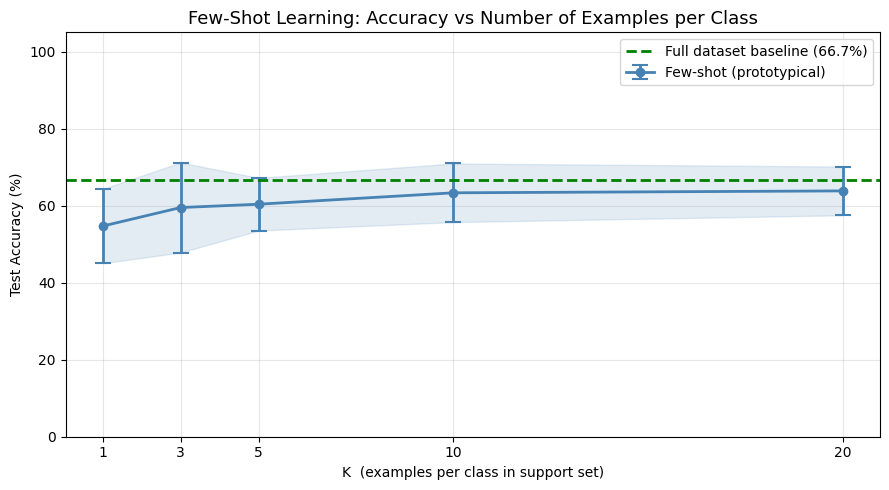

Few-shot curve saved: /content/drive/MyDrive/mars_project/phase3_few_shot_curve.png


In [8]:
means = [shot_results[k]['mean'] * 100 for k in k_values]
stds  = [shot_results[k]['std']  * 100 for k in k_values]

fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(k_values, means, yerr=stds,
            marker='o', linewidth=2, capsize=6, capthick=1.5,
            color='steelblue', label='Few-shot (prototypical)')
ax.fill_between(k_values,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.15, color='steelblue')
ax.axhline(y=full_acc, color='green', linestyle='--', linewidth=2,
           label=f'Full dataset baseline ({full_acc:.1f}%)')

ax.set_title('Few-Shot Learning: Accuracy vs Number of Examples per Class',
             fontsize=13)
ax.set_xlabel('K  (examples per class in support set)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_xticks(k_values)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase3_few_shot_curve.png')
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Few-shot curve saved: {out_path}")

CELL 9 — Anomaly / Out-of-Distribution Detection

In [13]:
# ─────────────────────────────────────────────
# CELL 9 — Anomaly / Out-of-Distribution Detection
# ─────────────────────────────────────────────

def compute_anomaly_scores(query_features, prototypes):
    """
    Returns normalized anomaly score [0,1] for each query image.
    Higher score = farther from all known class prototypes = more anomalous.
    """
    class_names  = list(prototypes.keys())
    proto_matrix = np.stack([prototypes[c] for c in class_names])  # (C, 128)

    min_dists = []
    for feat in query_features:
        diffs    = proto_matrix - feat[np.newaxis, :]
        dists    = np.sqrt((diffs ** 2).sum(axis=1))
        min_dists.append(dists.min())

    min_dists = np.array(min_dists)

    # ⬇️ THE NUMPY 2.0 FIX IS APPLIED HERE ⬇️
    scores    = (min_dists - min_dists.min()) / (np.ptp(min_dists) + 1e-8)

    return scores, min_dists


anomaly_scores, raw_dists = compute_anomaly_scores(test_features, prototypes_full)

# Softmax confidence from backbone
raw_preds      = backbone.predict(test_images, batch_size=16, verbose=0)
max_confidence = raw_preds.max(axis=1)
backbone_preds = np.argmax(raw_preds, axis=1)
correct        = (backbone_preds == test_enc)

CELL 10 — Anomaly detection plots

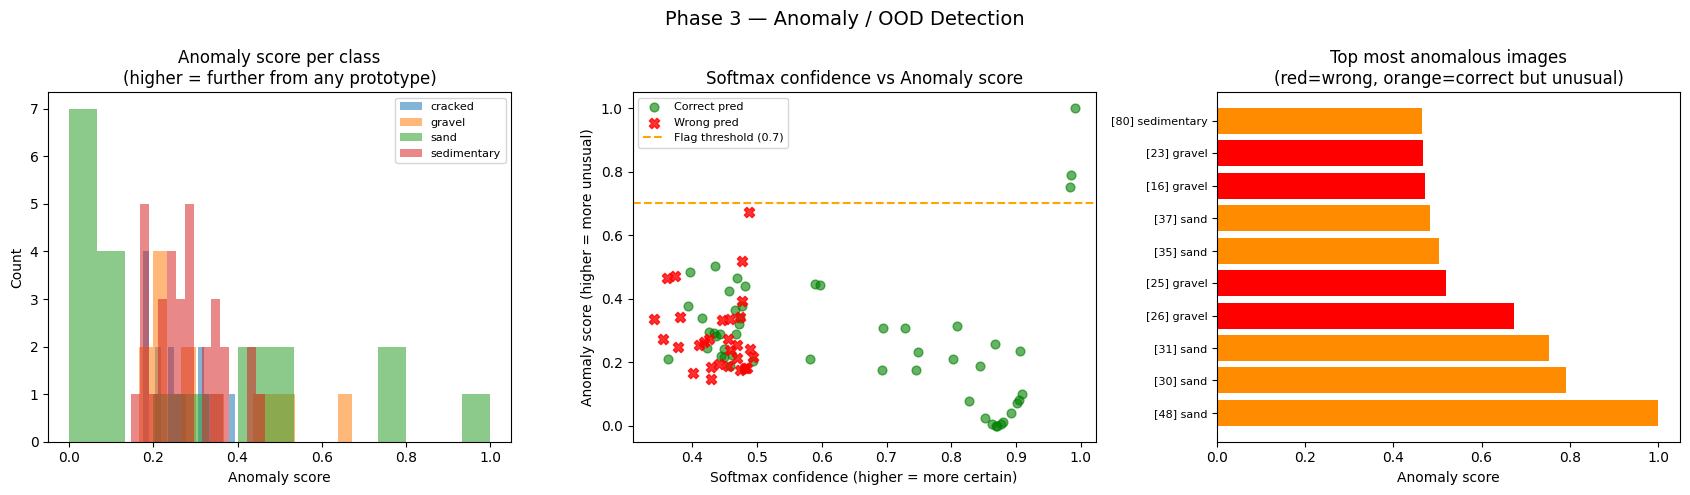

Anomaly plot saved: /content/drive/MyDrive/mars_project/phase3_anomaly.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Phase 3 — Anomaly / OOD Detection', fontsize=14)

# 1 — Anomaly score distribution per class
for cls_name in CLASS_NAMES:
    mask = test_labels == cls_name
    axes[0].hist(anomaly_scores[mask], alpha=0.55, label=cls_name, bins=15)
axes[0].set_title('Anomaly score per class\n(higher = further from any prototype)')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# 2 — Confidence vs anomaly score
axes[1].scatter(max_confidence[correct],  anomaly_scores[correct],
                alpha=0.6, c='green', s=40, label='Correct pred')
axes[1].scatter(max_confidence[~correct], anomaly_scores[~correct],
                alpha=0.8, c='red',   s=55, label='Wrong pred', marker='X')
axes[1].axhline(0.7, color='orange', linestyle='--', linewidth=1.5,
                label='Flag threshold (0.7)')
axes[1].set_title('Softmax confidence vs Anomaly score')
axes[1].set_xlabel('Softmax confidence (higher = more certain)')
axes[1].set_ylabel('Anomaly score (higher = more unusual)')
axes[1].legend(fontsize=8)

# 3 — Top uncertain images
safe_n       = min(10, len(anomaly_scores))
top_anomalous = np.argsort(anomaly_scores)[-safe_n:][::-1]
bar_cols      = ['red' if not correct[i] else 'darkorange' for i in top_anomalous]
axes[2].barh(range(safe_n), anomaly_scores[top_anomalous], color=bar_cols)
axes[2].set_yticks(range(safe_n))
axes[2].set_yticklabels(
    [f"[{i}] {test_labels[i]}" for i in top_anomalous], fontsize=8
)
axes[2].set_title('Top most anomalous images\n(red=wrong, orange=correct but unusual)')
axes[2].set_xlabel('Anomaly score')

plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase3_anomaly.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Anomaly plot saved: {out_path}")

CELL 11 — Confusion Matrix

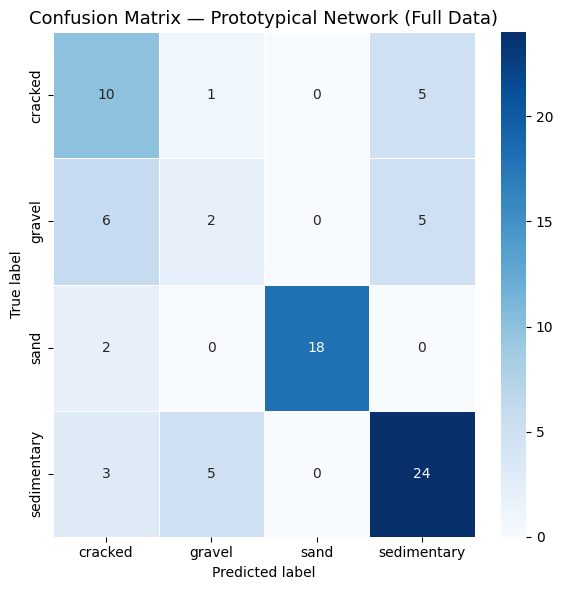

Confusion matrix saved: /content/drive/MyDrive/mars_project/phase3_confusion_matrix.png


In [15]:
cm = confusion_matrix(test_labels, preds_full, labels=CLASS_NAMES)

fig_size = max(6, NUM_CLASSES + 1)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5
)
ax.set_title('Confusion Matrix — Prototypical Network (Full Data)', fontsize=13)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
out_path = os.path.join(BASE_DIR, 'phase3_confusion_matrix.png')
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Confusion matrix saved: {out_path}")


CELL 12 — Save results summary (needed by Phase 4 demo)

In [16]:
flagged_count = int((anomaly_scores > 0.7).sum())

summary = {
    'class_names': CLASS_NAMES,
    'full_prototypical_acc': full_acc,
    'few_shot_results': shot_results,
    'anomaly_threshold': 0.7,
    'flagged_count': flagged_count,
}

import json
summary_path = os.path.join(BASE_DIR, 'phase3_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nSummary saved: {summary_path}")
print(f"\n{'='*50}")
print(f"PHASE 3 RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Full-data prototypical accuracy : {full_acc:.1f}%")
print(f"Few-shot performance:")
for k in k_values:
    print(f"   {k:>2d}-shot: {shot_results[k]['mean']*100:.1f}% ± {shot_results[k]['std']*100:.1f}%")
print(f"Anomalous images flagged (>0.7): {flagged_count} / {len(test_images)}")
print(f"{'='*50}")
print("\n✅ PHASE 3 COMPLETE — open Phase 4 notebook next")


Summary saved: /content/drive/MyDrive/mars_project/phase3_summary.json

PHASE 3 RESULTS SUMMARY
Full-data prototypical accuracy : 66.7%
Few-shot performance:
    1-shot: 54.7% ± 9.6%
    3-shot: 59.5% ± 11.7%
    5-shot: 60.4% ± 6.8%
   10-shot: 63.3% ± 7.6%
   20-shot: 63.8% ± 6.3%
Anomalous images flagged (>0.7): 3 / 81

✅ PHASE 3 COMPLETE — open Phase 4 notebook next
